# PlantDoc Test Evaluation — Swin Transformer

Evaluates the fine-tuned Swin model (`train_swin.ipynb` output) on the PlantDoc test set.

Requires: `pip install transformers==4.57.6 tf-keras==2.20.0`.

In [15]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tf_keras as keras
import transformers
from transformers import TFSwinForImageClassification
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("transformers:", transformers.__version__)

# --- BUGFIX: transformers 4.57 TFSwin window_reverse ---
import transformers.models.swin.modeling_tf_swin as _swin_tf


def _window_reverse_fixed(windows, window_size, height, width):
    x = tf.shape(windows)[0]
    y = (height * width) // (window_size * window_size)
    batch_size = tf.math.floordiv(x, y)

    windows = tf.reshape(
        windows,
        (
            batch_size,
            height // window_size,
            width // window_size,
            window_size,
            window_size,
            -1,
        ),
    )

    windows = tf.transpose(windows, (0, 1, 3, 2, 4, 5))

    return tf.reshape(windows, (batch_size, height, width, -1))


_swin_tf.window_reverse = _window_reverse_fixed

MODEL_DIR = "../models/swin/plantdoc_swin"
PLANTDOC_TRAIN = "../../PlantDoc/train"  # the folder the model was trained on
PLANTDOC_TEST = "../../PlantDoc/test"
OUTPUT_DIR = "../models/swin"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

for p in [MODEL_DIR, PLANTDOC_TRAIN, PLANTDOC_TEST]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

print("Loading PlantDoc Swin model...")

swin_model = TFSwinForImageClassification.from_pretrained(
    MODEL_DIR
)

print("Model loaded successfully.")

# The model's output index i = i-th sorted class folder of PLANTDOC_TRAIN.
model_class_names = sorted(
    d for d in os.listdir(PLANTDOC_TRAIN)
    if os.path.isdir(os.path.join(PLANTDOC_TRAIN, d))
)
print("[INFO] Model training classes:", len(model_class_names))
if swin_model.config.num_labels != len(model_class_names):
    raise ValueError(
        f"Class mismatch: model num_labels={swin_model.config.num_labels} "
        f"vs train folders={len(model_class_names)}."
    )

test_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TEST,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(
    "[INFO] Test batches:",
    tf.data.experimental.cardinality(test_ds).numpy()
)

TensorFlow: 2.20.0
transformers: 4.57.6
Loading PlantDoc Swin model...


All model checkpoint layers were used when initializing TFSwinForImageClassification.

All the layers of TFSwinForImageClassification were initialized from the model checkpoint at ../models/swin/plantdoc_swin.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinForImageClassification for predictions without further training.


Model loaded successfully.
[INFO] Model training classes: 28
Found 252 files belonging to 27 classes.
[INFO] Test batches: 8


In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class SwinClassifier(keras.Model):
    """Keras wrapper: [0,255] NHWC in -> logits out."""
    def __init__(self, swin_model, **kwargs):
        super().__init__(**kwargs)
        self.swin = swin_model
        self.rescale = keras.layers.Rescaling(1.0 / 255.0)
        self.normalization = keras.layers.Normalization(
            mean=IMAGENET_MEAN,
            variance=[s * s for s in IMAGENET_STD],
        )


    def call(self, inputs, training=False):
        x = self.rescale(inputs)
        x = self.normalization(x)
        x = tf.transpose(x, (0, 3, 1, 2))  # NHWC -> NCHW
        return self.swin(pixel_values=x, training=training).logits


model = SwinClassifier(swin_model)
model(tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3)))
print("[INFO] Model ready.")

[INFO] Model ready.


In [17]:
print("=" * 60)
print("PLANTDOC TEST EVALUATION")
print("=" * 60)

y_true = []
y_pred = []

for images, labels in test_ds:
    logits = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(logits, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Remap test labels into the model's class index space.
# The test folder lacks Tomato_two_spotted_spider_mite, so Keras
# assigns shifted labels to every class sorted after it — without
# this remap, correct predictions on those classes score as wrong.
# (Keras labels = sorted folder order, so we can rebuild it from disk;
# test_ds.class_names is unavailable after .prefetch().)
test_class_names = sorted(
    d for d in os.listdir(PLANTDOC_TEST)
    if os.path.isdir(os.path.join(PLANTDOC_TEST, d))
)
test_to_model = np.array(
    [model_class_names.index(n) for n in test_class_names]
)
y_true = test_to_model[y_true]

test_acc = float((y_true == y_pred).mean())
print(f"\n[RESULT] Test Accuracy: {test_acc:.4f}")
print(f"[RESULT] Test Accuracy (%): {test_acc * 100:.2f}%")
print(f"[INFO] Total test samples: {len(y_true)}")

PLANTDOC TEST EVALUATION

[RESULT] Test Accuracy: 0.6548
[RESULT] Test Accuracy (%): 65.48%
[INFO] Total test samples: 252


2026-09-13 07:57:16.002412: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(model_class_names)),
    target_names=model_class_names,
    digits=4,
    zero_division=0,  # Tomato_two_spotted_spider_mite has no test samples
)
print(report)

report_path = os.path.join(OUTPUT_DIR, "plantdoc_classification_report.txt")
with open(report_path, "w") as f:
    f.write("Plant Disease Detection - Swin Transformer\n")
    f.write("PlantDoc Test Classification Report\n\n")
    f.write(report)
print(f"[SUCCESS] Classification report saved to:\n{report_path}")

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

              Apple_cedar_rust     0.7273    0.8000    0.7619        10
                 Apple_healthy     0.5385    0.7778    0.6364         9
                    Apple_scab     0.7500    0.6000    0.6667        10
    Bell_pepper_bacterial_spot     0.8333    0.5556    0.6667         9
           Bell_pepper_healthy     0.5714    1.0000    0.7273         8
             Blueberry_healthy     1.0000    0.9091    0.9524        11
                Cherry_healthy     0.8000    0.8000    0.8000        10
              Corn_common_rust     0.9000    0.9000    0.9000        10
           Corn_gray_leaf_spot     0.1667    0.2500    0.2000         4
     Corn_northern_leaf_blight     0.7000    0.5833    0.6364        12
               Grape_black_rot     0.8750    0.8750    0.8750         8
                 Grape_healthy     0.9167    0.9167    0.9167        12
                 Peach_healthy     0.6667

CONFUSION MATRIX


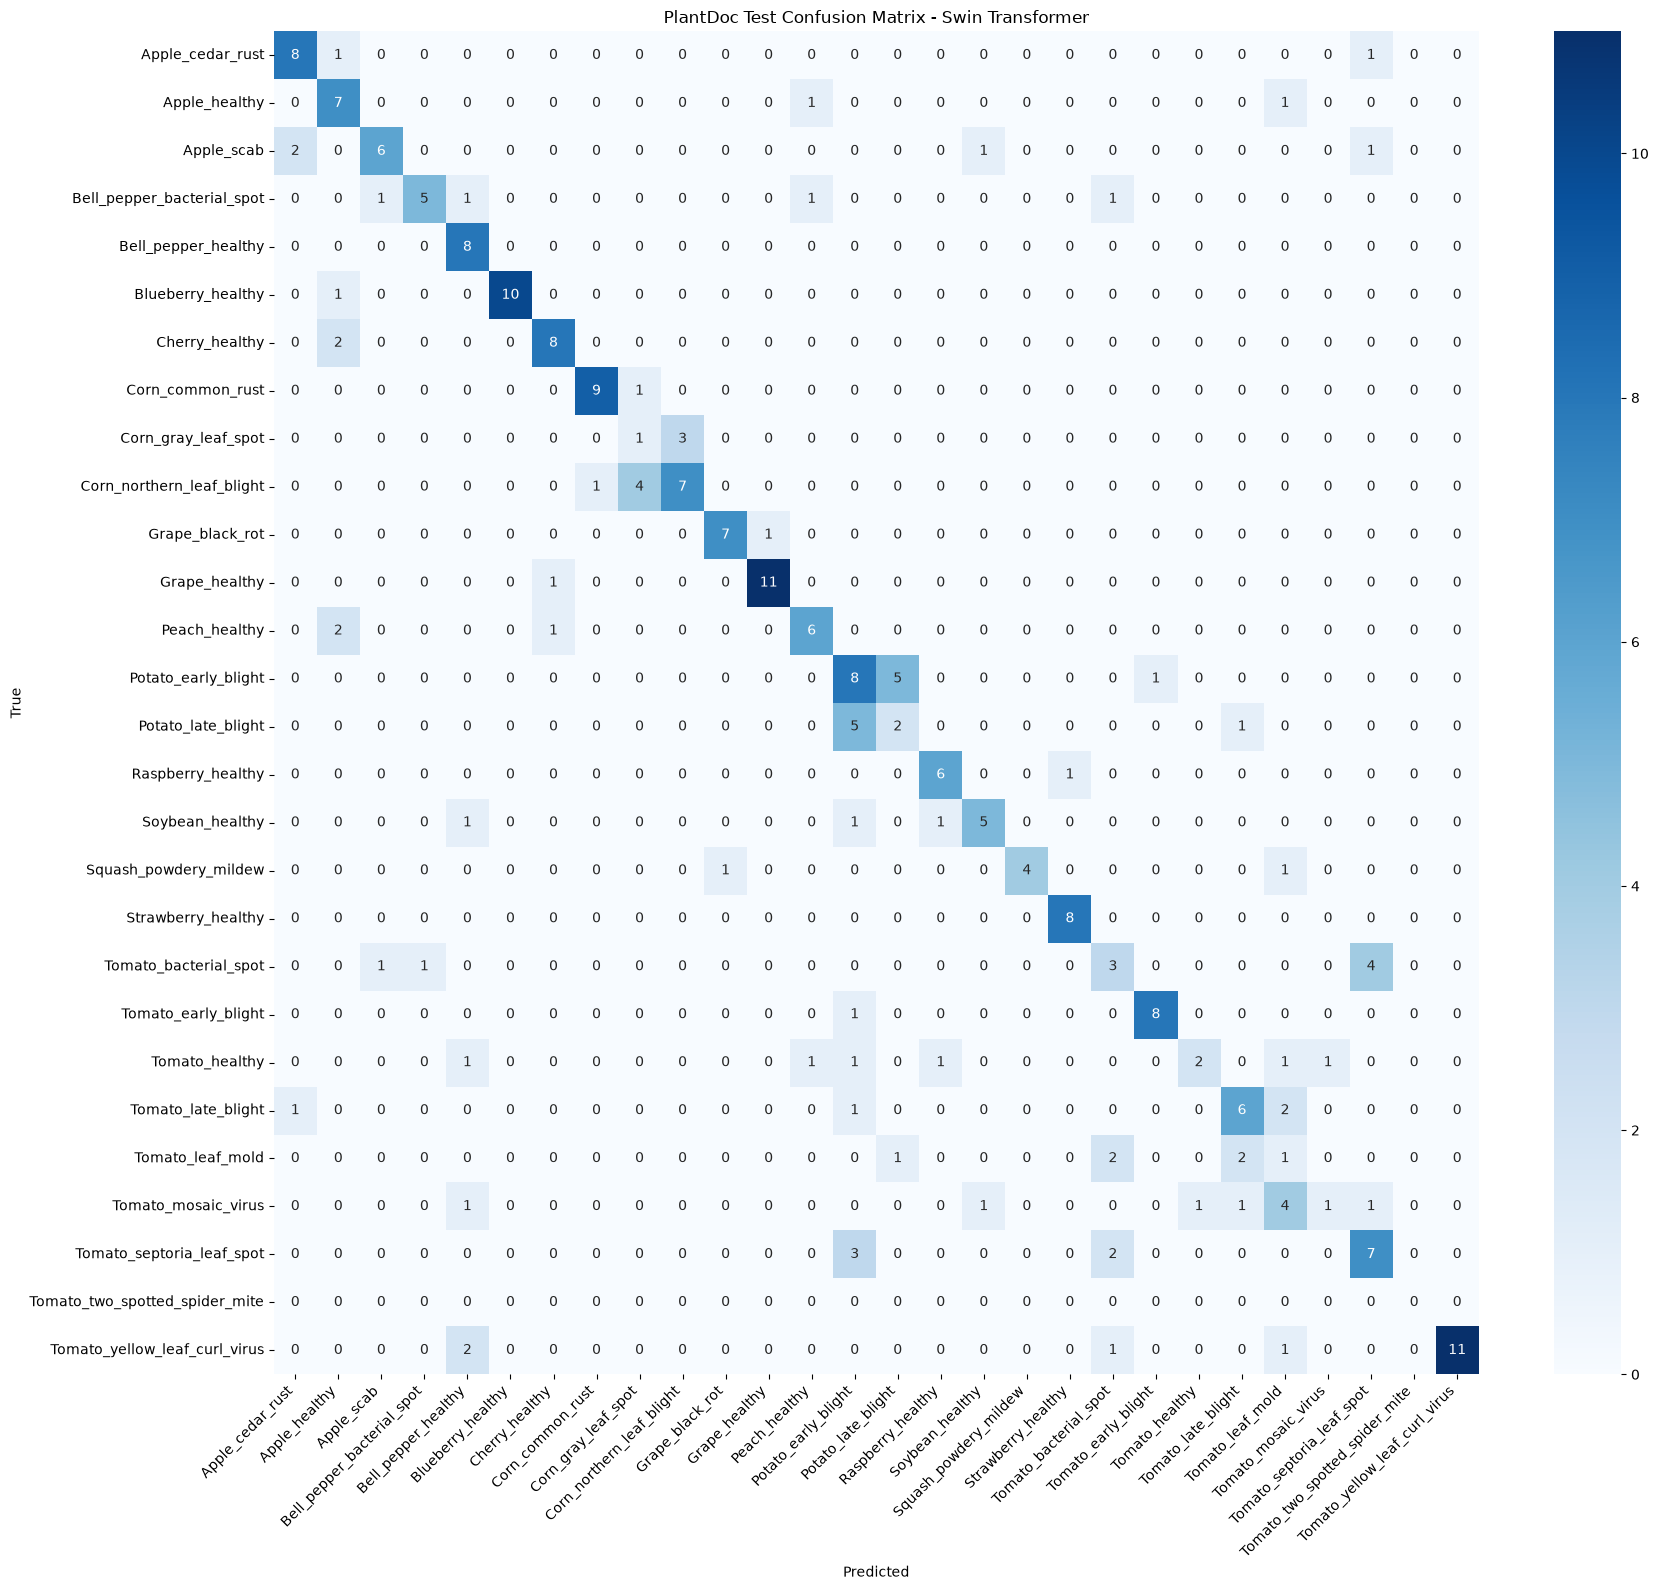

[SUCCESS] Confusion matrix saved to:
../models/swin/plantdoc_confusion_matrix.png


In [19]:
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    y_true, y_pred, labels=np.arange(len(model_class_names))
)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model_class_names,
    yticklabels=model_class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("PlantDoc Test Confusion Matrix - Swin Transformer")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "plantdoc_confusion_matrix.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"[SUCCESS] Confusion matrix saved to:\n{cm_path}")